# Gradient Boosting — Notes

## Core Idea
Gradient Boosting builds an ensemble of weak learners (usually shallow decision trees) **sequentially**, where each new tree tries to correct the errors (residuals) of the combined previous trees.

Loss function used (regression): 

$$L = (actual - pred)^2$$

Minimizing this loss leads to a key result:

$$\frac{\partial L}{\partial pred} \propto -(actual - pred)$$

So the **negative gradient of the loss = residual**. This is why:

> **actual − pred = pseudo-residual**

Each subsequent tree is trained to predict this pseudo-residual, not the original target.

⚠️ **Overfitting risk**: since each tree keeps fitting leftover residuals, too many trees / too deep trees can overfit the training data.

---

## Worked Example (from the board)

**Dataset**: predicting `salary` from `cgpa` (and other features like `iq`)

| cgpa | salary (actual) |
|------|------------------|
| 3    | 4.8 |
| 4    | 4.8 |
| 8    | 4.8 |
| 6    | 4.8 |
| 3    | 4.8 |

### Step 1 — Initial prediction (Model 0)
The first prediction (`pred1`) is just a constant — typically the **mean of the target**:

$$pred1 = 4.8 \text{ (for every row)}$$

### Step 2 — Compute residuals (res1)
$$res1 = actual - pred1$$

| cgpa | pred1 | res1 |
|------|-------|------|
| 3    | 4.8   | -1.8 |
| 4    | 4.8   | -0.8 |
| 8    | 4.8   |  3.2 |
| 6    | 4.8   |  1.2 |
| 3    | 4.8   | -1.8 |

### Step 3 — Fit Tree 1 on residuals (Model 1)
A decision tree is trained with **`res1` as the target** (not `salary`), using splits on other features like `iq`, `cgpa`:

```
              iq <= 105
             /          \
        iq <= 95      cgpa <= 7.5
        /     \          /      \
    -1.8    -0.8       3.2      1.2
```

Each leaf gives a predicted residual value (`-1.8`, `-0.8`, `3.2`, `1.2`) — this tree's output is `pred2`.

### Step 4 — Combine predictions
$$pred_{final} = m_1 + m_2 = pred1 + (\text{learning rate} \times \text{tree}_1\text{ output})$$

Example (row with cgpa=3, iq in lowest bucket):
$$pred = 4.8 + (-1.8) = 3.0 \text{ (before learning rate)}$$

With a learning rate (shrinkage) applied, the update is scaled down (e.g. `4.8 + η × (-1.8)`) to prevent overfitting and allow more trees to contribute gradually.

---

## General Algorithm Summary
1. Start with a base prediction (mean of target for regression).
2. Compute residuals = actual − predicted.
3. Fit a new tree to predict these residuals.
4. Update prediction: `new_pred = old_pred + learning_rate × tree_output`.
5. Repeat steps 2–4 for N trees (boosting rounds).
6. Final prediction = sum of all tree contributions (scaled by learning rate).

## Key Points to Remember
- Each tree corrects the **errors of the combined ensemble so far**, not the raw target.
- `actual - pred` = pseudo-residual = negative gradient of squared error loss.
- Learning rate controls how much each tree contributes → smaller rate + more trees = less overfitting but slower training.
- Too many boosting rounds without regularization → **overfitting** (as flagged on the board).

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
np.random.seed(4)

In [93]:
X=np.random.rand(100,1)-0.5
y=X[:,0]**2+0.05*np.random.randn(100)

In [94]:
import pandas as pd

In [95]:
df = pd.DataFrame()

In [96]:
df['X'] = X.reshape(100)
df['y']=y

In [97]:
df

,X,y
0,0.467030,0.189873
1,0.047232,-0.074916
2,0.472684,0.266973
3,0.214816,0.037385
4,0.197729,0.041527
...,...,...
95,-0.310974,0.149385
96,-0.027379,-0.030943
97,-0.107219,-0.007034
98,0.118930,-0.009033


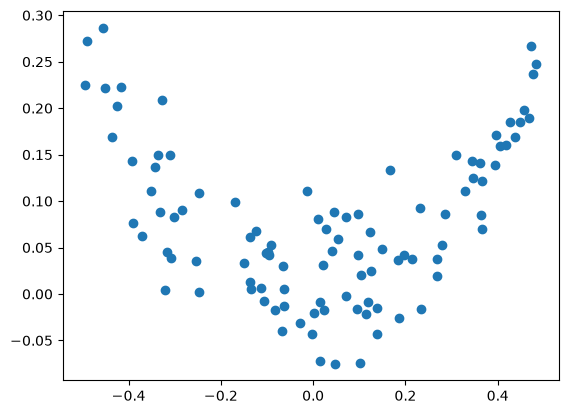

In [98]:
plt.scatter(X,y)

In [99]:
df['pred1'] = df['y'].mean()

In [100]:
df

,X,y,pred1
0,0.467030,0.189873,0.077272
1,0.047232,-0.074916,0.077272
2,0.472684,0.266973,0.077272
3,0.214816,0.037385,0.077272
4,0.197729,0.041527,0.077272
...,...,...,...
95,-0.310974,0.149385,0.077272
96,-0.027379,-0.030943,0.077272
97,-0.107219,-0.007034,0.077272
98,0.118930,-0.009033,0.077272


In [101]:
df['res1'] = df['y']-df['pred1']

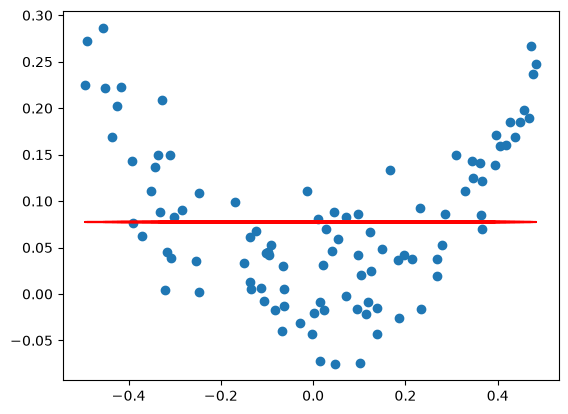

In [102]:

plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [103]:
from sklearn.tree import DecisionTreeRegressor

In [104]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(X,df['res1'])

,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several split

[Text(0.5909090909090909, 0.9, 'x[0] <= 0.298\nsquared_error = 0.007\nsamples = 100\nvalue = 0.0'),
 Text(0.36363636363636365, 0.7, 'x[0] <= -0.324\nsquared_error = 0.006\nsamples = 80\nvalue = -0.021'),
 Text(0.4772727272727273, 0.8, 'True  '),
 Text(0.18181818181818182, 0.5, 'x[0] <= -0.404\nsquared_error = 0.004\nsamples = 15\nvalue = 0.095'),
 Text(0.09090909090909091, 0.3, 'squared_error = 0.001\nsamples = 7\nvalue = 0.151'),
 Text(0.2727272727272727, 0.3, 'x[0] <= -0.329\nsquared_error = 0.002\nsamples = 8\nvalue = 0.045'),
 Text(0.18181818181818182, 0.1, 'squared_error = 0.001\nsamples = 7\nvalue = 0.033'),
 Text(0.36363636363636365, 0.1, 'squared_error = -0.0\nsamples = 1\nvalue = 0.131'),
 Text(0.5454545454545454, 0.5, 'x[0] <= -0.137\nsquared_error = 0.002\nsamples = 65\nvalue = -0.048'),
 Text(0.45454545454545453, 0.3, 'squared_error = 0.002\nsamples = 12\nvalue = -0.015'),
 Text(0.6363636363636364, 0.3, 'x[0] <= 0.144\nsquared_error = 0.002\nsamples = 53\nvalue = -0.056'),


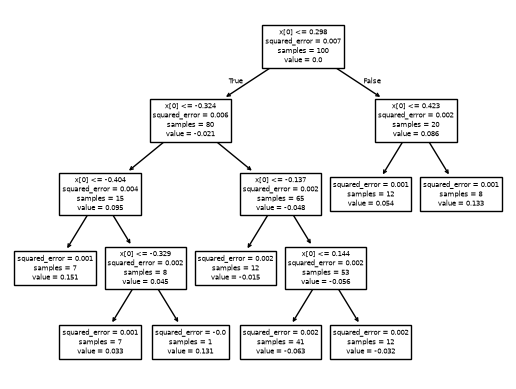

In [105]:
from sklearn.tree import plot_tree
plot_tree(tree1)

In [106]:
X_test = np.linspace(-0.5,0.5,500).reshape(500,1)
X_test.shape

(500, 1)

In [117]:
result = tree1.predict(X_test)

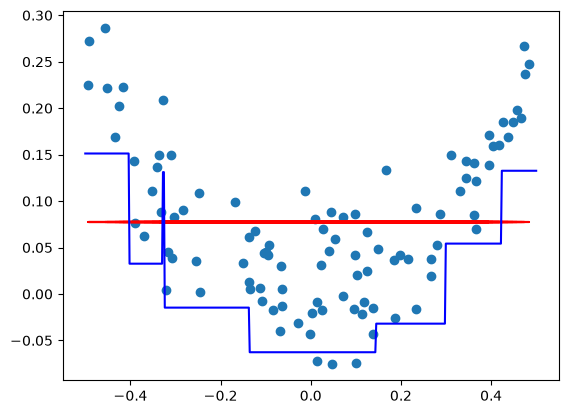

In [118]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')
plt.plot(X_test,result,c='blue')

In [119]:
df

,X,y,pred1,res1,pred2,res2
0,0.467030,0.189873,0.077272,0.112601,0.132630,0.057243
1,0.047232,-0.074916,0.077272,-0.152188,-0.062694,-0.012222
2,0.472684,0.266973,0.077272,0.189700,0.132630,0.134342
3,0.214816,0.037385,0.077272,-0.039887,-0.031931,0.069317
4,0.197729,0.041527,0.077272,-0.035745,-0.031931,0.073458
...,...,...,...,...,...,...
95,-0.310974,0.149385,0.077272,0.072113,-0.014680,0.164065
96,-0.027379,-0.030943,0.077272,-0.108215,-0.062694,0.031750
97,-0.107219,-0.007034,0.077272,-0.084306,-0.062694,0.055659
98,0.118930,-0.009033,0.077272,-0.086305,-0.062694,0.053661


In [120]:
df['pred2'] = tree1.predict(X)

In [121]:
df

,X,y,pred1,res1,pred2,res2
0,0.467030,0.189873,0.077272,0.112601,0.132630,0.057243
1,0.047232,-0.074916,0.077272,-0.152188,-0.062694,-0.012222
2,0.472684,0.266973,0.077272,0.189700,0.132630,0.134342
3,0.214816,0.037385,0.077272,-0.039887,-0.031931,0.069317
4,0.197729,0.041527,0.077272,-0.035745,-0.031931,0.073458
...,...,...,...,...,...,...
95,-0.310974,0.149385,0.077272,0.072113,-0.014680,0.164065
96,-0.027379,-0.030943,0.077272,-0.108215,-0.062694,0.031750
97,-0.107219,-0.007034,0.077272,-0.084306,-0.062694,0.055659
98,0.118930,-0.009033,0.077272,-0.086305,-0.062694,0.053661


In [122]:
df['res2'] = df['y']-df['pred2']

In [123]:
df

,X,y,pred1,res1,pred2,res2
0,0.467030,0.189873,0.077272,0.112601,0.132630,0.057243
1,0.047232,-0.074916,0.077272,-0.152188,-0.062694,-0.012222
2,0.472684,0.266973,0.077272,0.189700,0.132630,0.134342
3,0.214816,0.037385,0.077272,-0.039887,-0.031931,0.069317
4,0.197729,0.041527,0.077272,-0.035745,-0.031931,0.073458
...,...,...,...,...,...,...
95,-0.310974,0.149385,0.077272,0.072113,-0.014680,0.164065
96,-0.027379,-0.030943,0.077272,-0.108215,-0.062694,0.031750
97,-0.107219,-0.007034,0.077272,-0.084306,-0.062694,0.055659
98,0.118930,-0.009033,0.077272,-0.086305,-0.062694,0.053661


In [124]:
tree2= DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(X,df['res2'])


,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several split

In [127]:
result2 =tree2.predict(X_test)

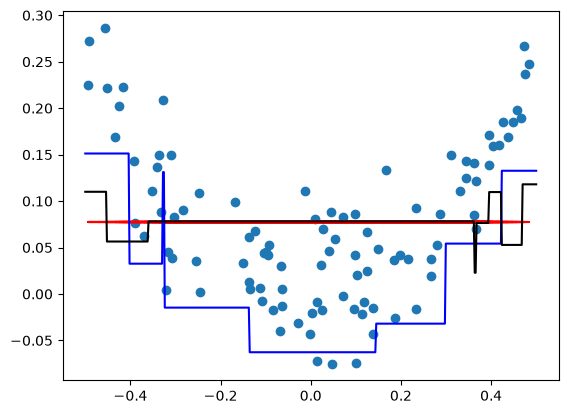

In [128]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')
plt.plot(X_test,result,c='blue')
plt.plot(X_test,result2,c='black')

In [131]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


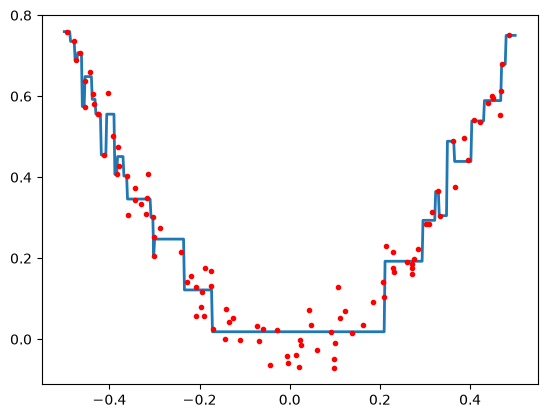

4


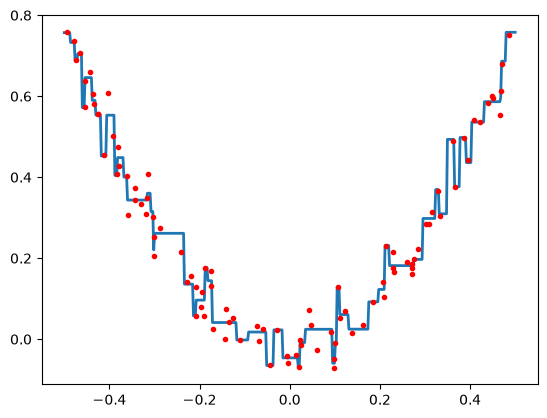

3


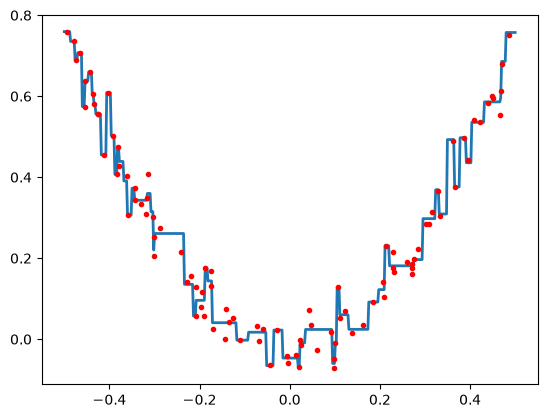

2


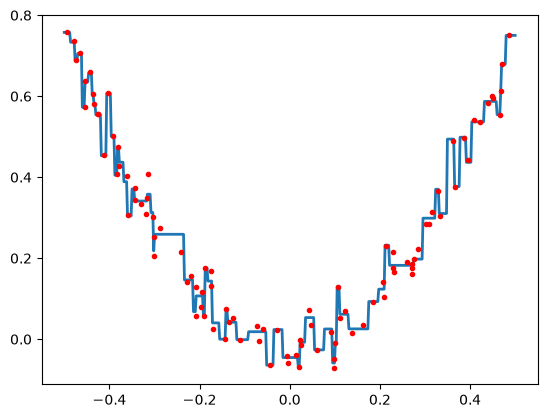

1


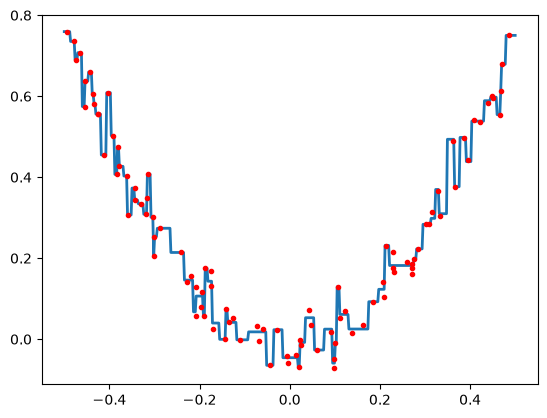

In [132]:

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)

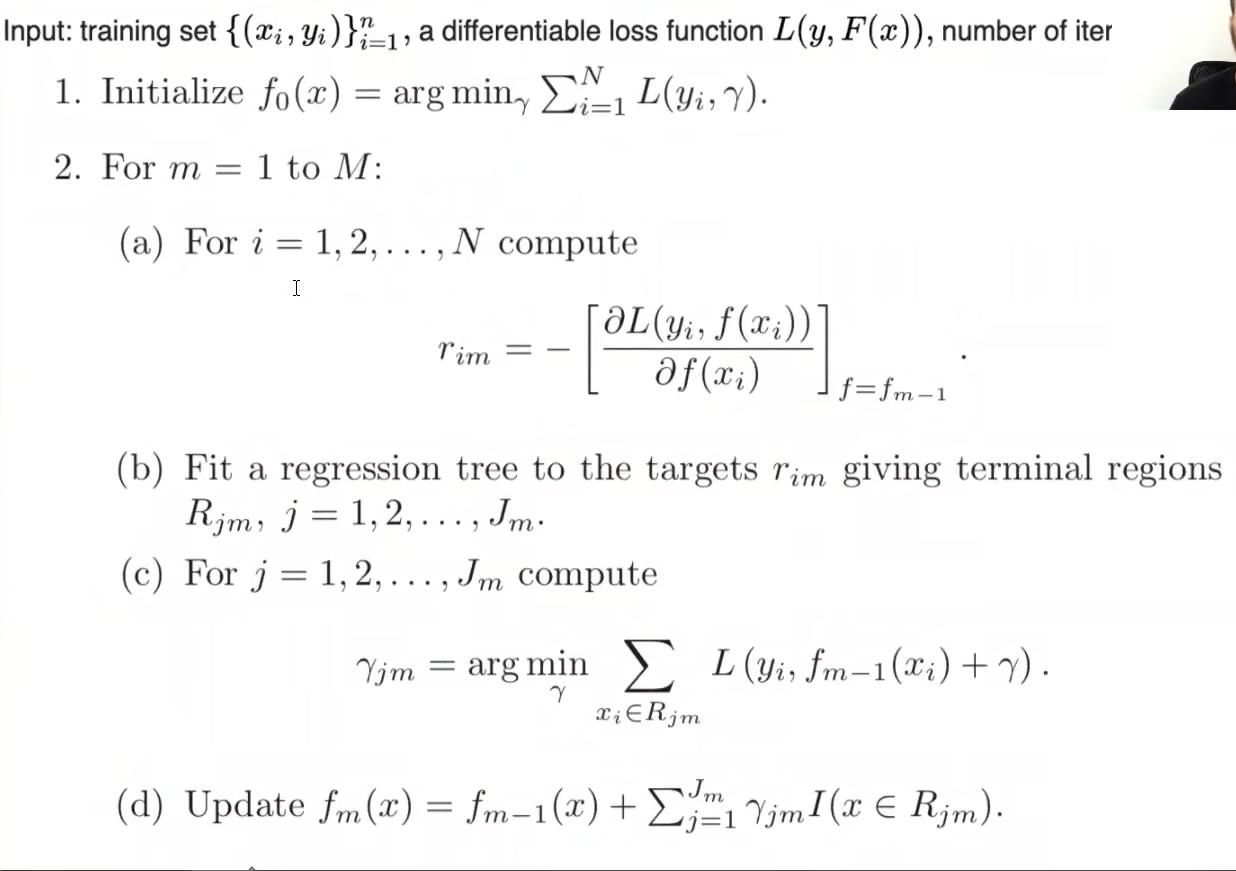